Aqui trabajamos con el dataset: https://www.kaggle.com/datasets/fedesoriano/cirrhosis-prediction-dataset

In [4]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib as plt

import seaborn as sns

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/cirrhosis-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.0k/11.0k [00:00<00:00, 6.90MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/cirrhosis-prediction-dataset/versions/2


In [2]:
import os
import pandas as pd

# List files in the downloaded dataset directory
files = os.listdir(path)
print("Files in dataset directory:", files)

# Assuming the CSV file is named 'cirrhosis.csv' based on the dataset name
csv_file_path = os.path.join(path, 'cirrhosis.csv')

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

Files in dataset directory: ['cirrhosis.csv']


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [3]:
from google.colab import files

# Save the DataFrame to a CSV file
output_filename = 'cirrhosis_data.csv'
df.to_csv(output_filename, index=False)

# Provide a link to download the file
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Asignamos un nombre para trabajar con mi base de datos

In [6]:
#Cargar la base de datos
Liver1 = pd.read_csv("cirrhosis_data.csv")




In [7]:
Liver1.shape

(418, 20)

Vemos los datos faltantes con .isnull().sum()

In [11]:
Liver1.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


Vemos el total de datos faltantes

In [9]:
Liver1.isnull().sum().sum()

np.int64(1033)

In [12]:
Liver1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [13]:
#veamos los datos que tiene Drug
Liver1['Drug'].unique()


array(['D-penicillamine', 'Placebo', nan], dtype=object)

Buscamos convertir las variables objec a float

In [14]:
# Crear un diccionario de mapeo
map_drug = {
    "D-penicillamine": 0,
    "Placebo": 1
}

# Reemplazar valores en la columna Drug
Liver1["Drug"] = Liver1["Drug"].map(map_drug)

# Ver los primeros registros para confirmar
Liver1["Drug"].head()


,Drug
0,0.0
1,0.0
2,0.0
3,0.0
4,1.0


In [15]:
# Reemplazar NaN por el valor 2 (Desconocido)
Liver1["Drug"] = Liver1["Drug"].map({
    "D-penicillamine": 0,
    "Placebo": 1
}).fillna(2)

# Confirmar los primeros registros
Liver1["Drug"].head()


,Drug
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0


vamos con la siguiente variable Ascites

In [22]:
#veamos los datos que tiene Ascites
Liver1['Ascites'].unique()


array([1., 0., 2.])

In [19]:
Liver1["Ascites"] = Liver1["Ascites"].map({
    "Y": 1,
    "N": 0
}).fillna(2)

# Confirmar los primeros registros
Liver1["Ascites"].head()


,Ascites
0,1.0
1,0.0
2,0.0
3,0.0
4,0.0


Vamos con la variable Hepatomegaly

In [23]:
#veamos los datos que tiene Hepatomegaly
Liver1['Hepatomegaly'].unique()

array(['Y', 'N', nan], dtype=object)

In [24]:
Liver1["Hepatomegaly"] = Liver1["Hepatomegaly"].map({
    "Y": 1,
    "N": 0
}).fillna(2)

# Confirmar los primeros registros
Liver1["Hepatomegaly"].head()


,Hepatomegaly
0,1.0
1,1.0
2,0.0
3,1.0
4,1.0


Vamos con la variable Spiders

In [26]:
#veamos los datos que tiene Spiders
Liver1['Spiders'].unique()

array(['Y', 'N', nan], dtype=object)

In [27]:
Liver1["Spiders"] = Liver1["Spiders"].map({
    "Y": 1,
    "N": 0
}).fillna(2)

# Confirmar los primeros registros
Liver1["Spiders"].head()


,Spiders
0,1.0
1,1.0
2,0.0
3,1.0
4,1.0


In [28]:
Liver1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           418 non-null    float64
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        418 non-null    float64
 7   Hepatomegaly   418 non-null    float64
 8   Spiders        418 non-null    float64
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [29]:
#veamos los datos que tiene Cholesterol
Liver1['Cholesterol'].unique()

array([ 261.,  302.,  176.,  244.,  279.,  248.,  322.,  280.,  562.,
        200.,  259.,  236.,  281.,   nan,  231.,  204.,  274.,  178.,
        235.,  374.,  252.,  271.,  395.,  456.,  298., 1128.,  175.,
        222.,  370.,  260.,  296.,  262.,  210.,  364.,  314.,  172.,
        334.,  383.,  282.,  361.,  299.,  482.,  316.,  257.,  276.,
        614.,  288.,  416.,  498.,  242.,  329.,  604.,  216.,  932.,
        373.,  256.,  427.,  466.,  174.,  652.,  258.,  320.,  132.,
        558.,  674.,  394.,  436.,  315.,  247.,  448.,  472.,  250.,
        263., 1600.,  345.,  408.,  660.,  325.,  206.,  353.,  201.,
        420.,  239.,  460.,  400.,  188.,  303.,  464.,  212.,  127.,
        120.,  486.,  528.,  267.,  458.,  950.,  390.,  636.,  151.,
        251.,  269.,  268., 1775.,  331.,  578.,  399.,  426.,  328.,
        290.,  346.,  332.,  556.,  309., 1015.,  586.,  217.,  168.,
        220.,  358.,  286.,  450.,  317.,  502.,  233.,  196., 1480.,
        376.,  205.,

En este caso agregamos los valores nulos con la mediana

In [30]:
median_chol = Liver1["Cholesterol"].median()
Liver1["Cholesterol"] = Liver1["Cholesterol"].fillna(median_chol)

# Confirmar que ya no hay NaN
Liver1["Cholesterol"].isnull().sum()


np.int64(0)

Vamos con Copper

In [33]:
median_copper = Liver1["Copper"].median()
Liver1["Copper"] = Liver1["Copper"].fillna(median_copper)

# Confirmar que ya no hay NaN
Liver1["Copper"].isnull().sum()


np.int64(0)

Ahora la variable Alk_Phos

In [34]:
median_alk = Liver1["Alk_Phos"].median()
Liver1["Alk_Phos"] = Liver1["Alk_Phos"].fillna(median_alk)

# Confirmar que ya no hay NaN
Liver1["Alk_Phos"].isnull().sum()


np.int64(0)

Ahora para SGOT

In [35]:
median_sgot = Liver1["SGOT"].median()
Liver1["SGOT"] = Liver1["SGOT"].fillna(median_sgot)

# Confirmar que ya no hay NaN
Liver1["SGOT"].isnull().sum()


np.int64(0)

Vamos con Tryglicerides

In [37]:
median_Tryglicerides = Liver1["Tryglicerides"].median()
Liver1["Tryglicerides"] = Liver1["Tryglicerides"].fillna(median_Tryglicerides)

# Confirmar que ya no hay NaN
Liver1["Tryglicerides"].isnull().sum()


np.int64(0)

Vamos con Platelets

In [38]:
median_Platelets = Liver1["Platelets"].median()
Liver1["Platelets"] = Liver1["Platelets"].fillna(median_Platelets)

# Confirmar que ya no hay NaN
Liver1["Platelets"].isnull().sum()

np.int64(0)

Para Prothrombin

In [39]:
median_prot = Liver1["Prothrombin"].median()
Liver1["Prothrombin"] = Liver1["Prothrombin"].fillna(median_prot)

# Confirmar que ya no hay NaN
Liver1["Prothrombin"].isnull().sum()


np.int64(0)

In [40]:
Liver1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           418 non-null    float64
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        418 non-null    float64
 7   Hepatomegaly   418 non-null    float64
 8   Spiders        418 non-null    float64
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    418 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         418 non-null    float64
 14  Alk_Phos       418 non-null    float64
 15  SGOT           418 non-null    float64
 16  Tryglicerides  418 non-null    float64
 17  Platelets      418 non-null    float64
 18  Prothrombi

Para Stage

In [41]:
median_stage = Liver1["Stage"].median()
Liver1["Stage"] = Liver1["Stage"].fillna(median_stage)

# Confirmar que ya no hay NaN
Liver1["Stage"].isnull().sum()


np.int64(0)

Veamos las variables que son objec y convertirlas en int64 o float64

In [42]:
#veamos los datos que tiene Status
Liver1['Status'].unique()

array(['D', 'C', 'CL'], dtype=object)

In [43]:
Liver1["Status"] = Liver1["Status"].map({
    "D": 0,
    "C": 1,
    "CL": 2
})

# Confirmar los primeros registros
Liver1["Status"].head()


,Status
0,0
1,1
2,0
3,0
4,2


Veamos Edema

In [44]:
#veamos los datos que tiene Edema
Liver1['Edema'].unique()

array(['Y', 'N', 'S'], dtype=object)

In [45]:
Liver1["Edema"] = Liver1["Edema"].map({
    "Y": 1,
    "N": 0,
    "S": 2
})

# Confirmar los primeros registros
Liver1["Edema"].head()


,Edema
0,1
1,0
2,2
3,2
4,0


Veamos Sex

In [47]:
#veamos los datos que tiene Sex
Liver1['Sex'].unique()

array(['F', 'M'], dtype=object)

In [48]:
Liver1["Sex"] = Liver1["Sex"].map({
    "F": 0,
    "M": 1
})

# Confirmar los primeros registros
Liver1["Sex"].head()


,Sex
0,0
1,0
2,1
3,0
4,0


Verificamosque todos los datos esten sin valores nulos y sean int64 o float64

In [49]:
Liver1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    int64  
 3   Drug           418 non-null    float64
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    int64  
 6   Ascites        418 non-null    float64
 7   Hepatomegaly   418 non-null    float64
 8   Spiders        418 non-null    float64
 9   Edema          418 non-null    int64  
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    418 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         418 non-null    float64
 14  Alk_Phos       418 non-null    float64
 15  SGOT           418 non-null    float64
 16  Tryglicerides  418 non-null    float64
 17  Platelets      418 non-null    float64
 18  Prothrombi

Vemos si hay duplicados

In [50]:
Liver1.drop_duplicates(inplace=True)

In [51]:
Liver1.describe()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.0,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,209.500000,1917.782297,0.674641,2.0,18533.351675,0.105263,0.564593,0.889952,0.722488,0.258373,3.220813,350.272727,3.497440,91.279904,1799.144976,120.564067,119.267943,256.866029,10.731100,3.023923
std,120.810458,1104.672992,0.583036,0.0,3815.845055,0.307260,0.868798,0.778823,0.842243,0.634907,4.407506,193.123893,0.424972,74.485481,1875.121982,49.085094,54.050691,97.024861,1.019587,0.875678
min,1.000000,41.000000,0.000000,2.0,9598.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,0.000000,2.0,15644.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,273.000000,3.242500,51.250000,1016.250000,91.000000,95.000000,190.000000,10.000000,2.000000
50%,209.500000,1730.000000,1.000000,2.0,18628.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,1.000000,2.0,21272.500000,0.000000,2.000000,2.000000,2.000000,0.000000,3.400000,347.750000,3.770000,100.750000,1707.750000,135.750000,127.750000,315.500000,11.100000,4.000000
max,418.000000,4795.000000,2.000000,2.0,28650.000000,1.000000,2.000000,2.000000,2.000000,2.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


Vease un Boxplot

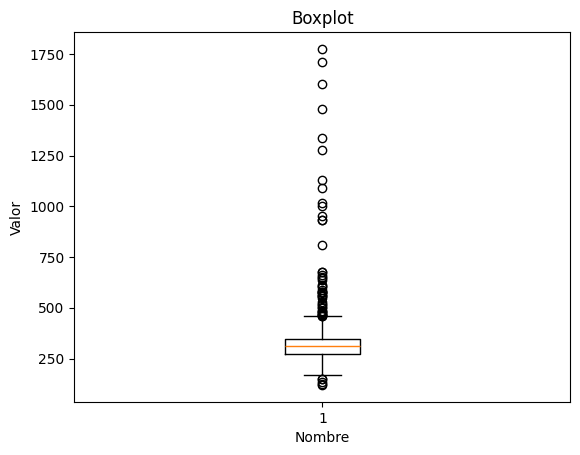

In [52]:
# Crear un boxplot para Liver1
import matplotlib.pyplot as plt

plt.boxplot(Liver1['Cholesterol'])
plt.xlabel('Nombre')       # etiqueta del eje X
plt.ylabel('Valor')        # etiqueta del eje Y
plt.title('Boxplot')       # título del gráfico

# Mostrar gráfico
plt.show()


Vease el histograma

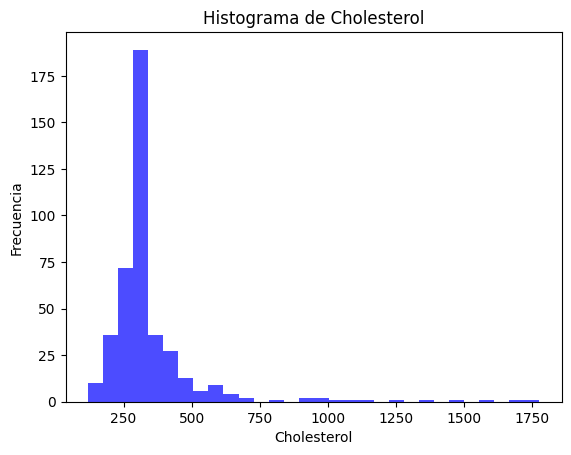

In [53]:
# Crear histograma para Liver1
import matplotlib.pyplot as plt

plt.hist(Liver1['Cholesterol'], bins=30, color='blue', alpha=0.7)
# Añadir etiquetas y título
plt.xlabel('Cholesterol')
plt.ylabel('Frecuencia')
plt.title('Histograma de Cholesterol')

# Mostrar el histograma
plt.show()


In [54]:
from google.colab import files

# Save the Liver1 DataFrame to a CSV file
output_filename_liver1 = 'Liver1_processed.csv'
Liver1.to_csv(output_filename_liver1, index=False)

# Provide a link to download the file
files.download(output_filename_liver1)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>